# User Retention and Funnel Analysis

**Domain:** Product Analytics  
**Dataset:** Online Retail II Dataset (UCI Machine Learning Repository)  
**Language:** Python  

---

## Business Problem

Understanding how customers move through a purchase funnel, how many return after their first purchase, and when cohorts tend to disengage are foundational product analytics questions. Retention curves and cohort analysis directly inform product decisions — onboarding improvements, re-engagement campaigns, loyalty programmes — and are a standard component of growth analytics in any consumer-facing business. The same methodology applies to insurance renewal cycles, patient re-engagement in healthcare, and subscription retention in SaaS.

This project implements a full cohort retention and funnel analysis workflow using transactional retail data, producing the standard outputs a product analyst or growth team would present to stakeholders.

**Central question:** *What proportion of customers return after their first purchase, when do cohorts typically disengage, and what factors predict conversion to repeat buyers?*

---

**Notebook structure:**
1. Setup
2. Data ingestion & cleaning
3. Cohort construction
4. Retention analysis
5. Revenue per cohort & LTV curves
6. Funnel analysis
7. RFM segmentation
8. Results summary

---
*industry_projects - Samantha McGarrigle*

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')

# ── Plot defaults ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Colour palette ─────────────────────────────────────────────────────────
BLUE   = '#2C7BB6'
ORANGE = '#E08C34'
GREEN  = '#3A9E6F'
RED    = '#C0392B'
GREY   = '#7F8C8D'

print('Setup complete.')

Setup complete.


## 2. Data Ingestion & Cleaning

The Online Retail II dataset covers all transactions from a UK-based online retailer between December 2009 and December 2011. It is a real transactional dataset with enough complexity — cancellations, multi-item orders, missing customer IDs, international customers — to require careful cleaning before analysis.

**Download:** [UCI ML Repository — Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
Save both sheets (`Year 2009-2010` and `Year 2010-2011`) as a single Excel file named `online_retail_II.xlsx` in the working directory, or adjust the path below.

**Cleaning steps:**
- Remove cancelled transactions (InvoiceNo prefixed with `C`)
- Remove rows with missing `Customer ID`
- Remove rows with non-positive `Quantity` or `Price`
- Compute order-level revenue: `Quantity × Price`
- Parse `InvoiceDate` to datetime and extract invoice month

In [2]:
# ── Load both years and concatenate ───────────────────────────────────────
df_09 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2009-2010', dtype={'Customer ID': str})
df_10 = pd.read_excel('data/online_retail_II.xlsx', sheet_name='Year 2010-2011', dtype={'Customer ID': str})
raw   = pd.concat([df_09, df_10], ignore_index=True)

In [3]:
# ── Inspect missingness before cleaning ───────────────────────────────────
print('Missing values per column:')
print(raw.isnull().sum())
print(f'\nCancellation rows (Invoice starts with C): {raw["Invoice"].astype(str).str.startswith("C").sum():,}')

Missing values per column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Cancellation rows (Invoice starts with C): 19,494


In [4]:
# ── Apply cleaning rules ──────────────────────────────────────────────────
df = (
    raw
    # Drop cancellations
    .loc[~raw['Invoice'].astype(str).str.startswith('C')]
    # Drop missing Customer ID
    .dropna(subset=['Customer ID'])
    # Drop non-positive quantity or price (data entry errors)
    .loc[lambda x: (x['Quantity'] > 0) & (x['Price'] > 0)]
    # Parse invoice date
    .assign(
        InvoiceDate = lambda x: pd.to_datetime(x['InvoiceDate']),
        InvoiceMonth = lambda x: x['InvoiceDate'].dt.to_period('M'),
        Revenue = lambda x: x['Quantity'] * x['Price'],
        CustomerID = lambda x: x['Customer ID'].str.strip(),
    )
    .drop(columns=['Customer ID'])
    .reset_index(drop=True)
)

print(f'Clean rows: {len(df):,}')
print(f'Unique customers: {df["CustomerID"].nunique():,}')
print(f'Date range: {df["InvoiceDate"].min().date()} → {df["InvoiceDate"].max().date()}')
print(f'Total revenue: £{df["Revenue"].sum():,.0f}')

Clean rows: 805,549
Unique customers: 5,878
Date range: 2009-12-01 → 2011-12-09
Total revenue: £17,743,429


In [5]:
# ── Transaction-level summary statistics ──────────────────────────────────
df[['Quantity', 'Price', 'Revenue']].describe().round(2)

,Quantity,Price,Revenue
count,805549.00,805549.00,805549.00
mean,13.29,3.21,22.03
std,143.63,29.20,224.04
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,5.00,1.95,11.85
75%,12.00,3.75,19.50
max,80995.00,10953.50,168469.60


### Interpretation

After removing cancellations, missing customer identifiers, and implausible values, the cleaned dataset retains the large majority of rows. Revenue is right-skewed — a small number of high-value orders pull the mean above the median, which is typical of B2B-leaning retail datasets. All downstream analyses operate at the customer and invoice level rather than the line-item level to avoid double-counting.

## 3. Cohort Construction

Each customer is assigned to an **acquisition cohort** defined by the calendar month of their first purchase. For each subsequent transaction, we compute the number of months elapsed since acquisition. This produces the cohort × period matrix needed for retention analysis.

The unit of observation for retention is **customer × cohort period** — whether a given customer made at least one purchase in a given month relative to their acquisition month.

In [6]:
# ── Collapse to one row per customer × invoice month ──────────────────────
# (avoids double-counting customers with multiple orders in the same month)
customer_months = (
    df
    .groupby(['CustomerID', 'InvoiceMonth'], as_index=False)
    .agg(MonthRevenue=('Revenue', 'sum'))
)

# ── Acquisition month = first InvoiceMonth per customer ──────────────────
acquisition = (
    customer_months
    .groupby('CustomerID')['InvoiceMonth']
    .min()
    .rename('CohortMonth')
    .reset_index()
)

# ── Merge acquisition month back onto customer × month table ─────────────
cohort_df = customer_months.merge(acquisition, on='CustomerID')

# ── Compute months since acquisition (cohort period) ─────────────────────
cohort_df['CohortPeriod'] = (
    cohort_df['InvoiceMonth'] - cohort_df['CohortMonth']
).apply(lambda x: x.n)   # .n gives the integer number of periods

print(f'Cohort table rows: {len(cohort_df):,}')
print(f'Cohorts (acquisition months): {cohort_df["CohortMonth"].nunique()}')
print(f'Max cohort period observed: {cohort_df["CohortPeriod"].max()} months')
cohort_df.head()

Cohort table rows: 25,595
Cohorts (acquisition months): 25
Max cohort period observed: 24 months


,CustomerID,InvoiceMonth,MonthRevenue,CohortMonth,CohortPeriod
0,12346,2009-12,113.50,2009-12,0
1,12346,2010-01,90.00,2009-12,1
2,12346,2010-03,27.05,2009-12,3
3,12346,2010-06,142.31,2009-12,6
4,12346,2011-01,77183.60,2009-12,13


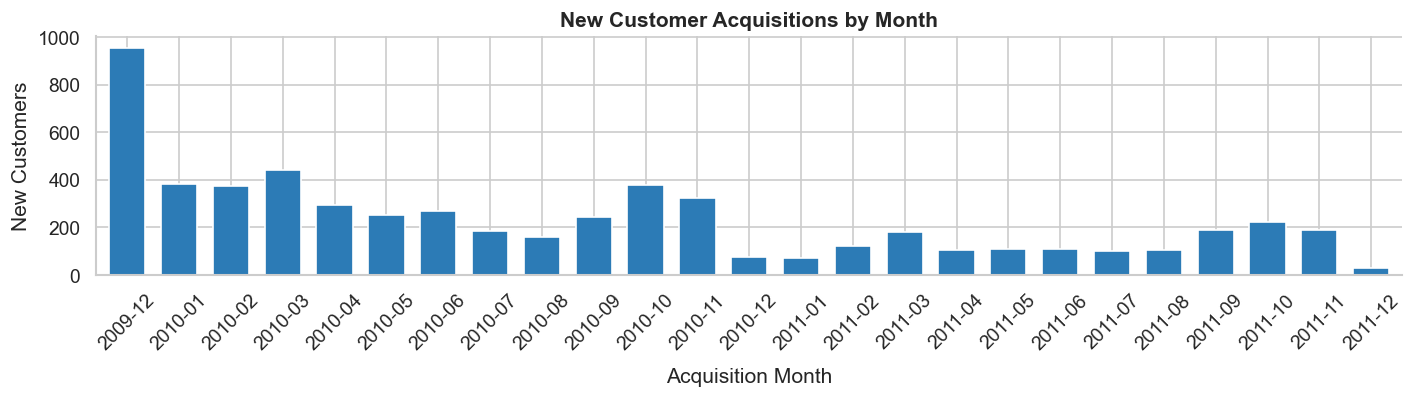

In [7]:
# ── Cohort sizes — number of unique customers acquired each month ─────────
cohort_sizes = (
    cohort_df
    .loc[cohort_df['CohortPeriod'] == 0]
    .groupby('CohortMonth')['CustomerID']
    .nunique()
    .rename('CohortSize')
)

fig, ax = plt.subplots(figsize=(12, 3.5))
cohort_sizes.plot(kind='bar', ax=ax, color=BLUE, width=0.7)
ax.set_xlabel('Acquisition Month', labelpad=8)
ax.set_ylabel('New Customers')
ax.set_title('New Customer Acquisitions by Month', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Retention Analysis

### 4.1 Cohort Retention Matrix

The retention matrix shows, for each acquisition cohort, the **percentage of customers who made at least one purchase** in each subsequent month. Period 0 is always 100% (the acquisition month itself). The matrix is the standard product analytics deliverable for retention — it makes cohort-level patterns visible at a glance.

In [8]:
# ── Count distinct customers per cohort × period ─────────────────────────
cohort_counts = (
    cohort_df
    .groupby(['CohortMonth', 'CohortPeriod'])['CustomerID']
    .nunique()
    .reset_index(name='Customers')
)

# ── Pivot to cohort × period matrix ──────────────────────────────────────
retention_matrix = cohort_counts.pivot_table(
    index='CohortMonth',
    columns='CohortPeriod',
    values='Customers'
)

# ── Divide each row by cohort size (period 0) to get retention rate ───────
retention_pct = retention_matrix.divide(retention_matrix[0], axis=0) * 100

# ── Trim to periods 0–12 for readability ─────────────────────────────────
retention_pct = retention_pct.loc[:, 0:12]

# ── Format index as strings for cleaner heatmap labels ───────────────────
retention_pct.index = retention_pct.index.astype(str)

print(f'Retention matrix shape: {retention_pct.shape}')

Retention matrix shape: (25, 13)


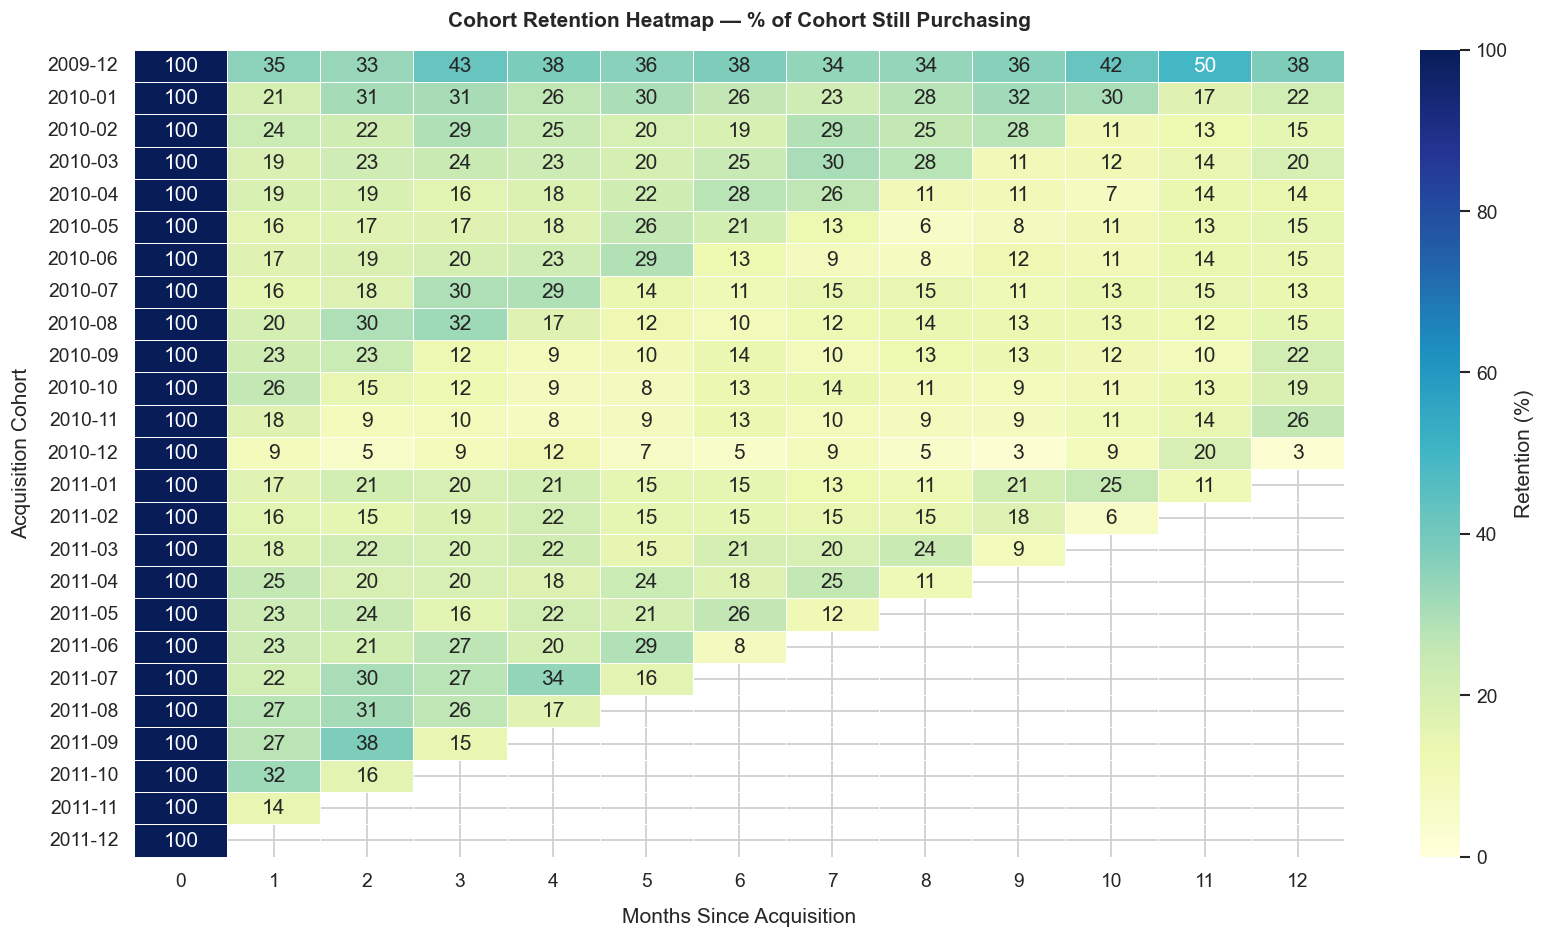

In [9]:
# ── Cohort retention heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    retention_pct,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Retention (%)'},
    vmin=0,
    vmax=100,
    ax=ax,
)

ax.set_xlabel('Months Since Acquisition', labelpad=10)
ax.set_ylabel('Acquisition Cohort', labelpad=10)
ax.set_title('Cohort Retention Heatmap — % of Cohort Still Purchasing', fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

### 4.2 Retention Curves by Cohort

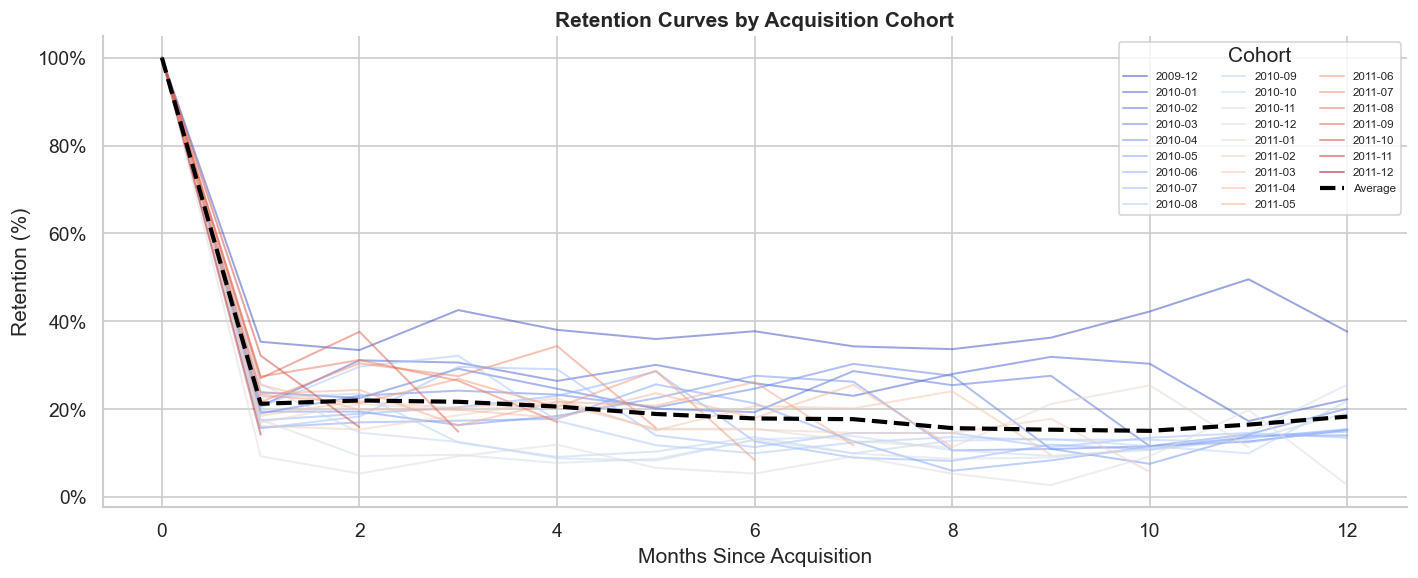

In [10]:
# ── Retention curves — one line per cohort ────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

cmap = plt.cm.get_cmap('coolwarm', len(retention_pct))

for i, (cohort, row) in enumerate(retention_pct.iterrows()):
    valid = row.dropna()
    ax.plot(
        valid.index, valid.values,
        color=cmap(i), alpha=0.5, linewidth=1.2, label=str(cohort)
    )

# Average retention curve across all cohorts
avg_retention = retention_pct.mean()
ax.plot(
    avg_retention.index, avg_retention.values,
    color='black', linewidth=2.5, linestyle='--', label='Average'
)

ax.set_xlabel('Months Since Acquisition')
ax.set_ylabel('Retention (%)')
ax.set_title('Retention Curves by Acquisition Cohort', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc='upper right', ncol=3, fontsize=7, title='Cohort')
plt.tight_layout()
plt.show()

### 4.3 Headline KPIs: Month-1 and Month-3 Retention

Month-1 Retention (% of cohort returning after 1 month):
  Mean:   21.2%
  Median: 20.5%
  Range:  9.2% – 35.3%

Month-3 Retention:
  Mean:   21.6%
  Median: 20.0%
  Range:  9.2% – 42.5%


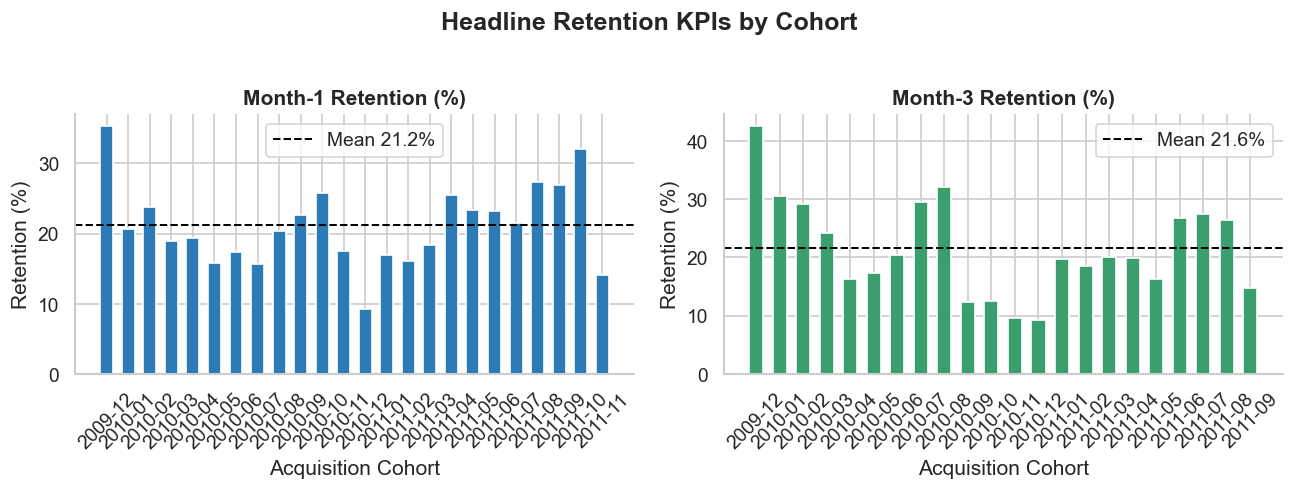

In [11]:
# ── Month-1 and Month-3 retention rates ───────────────────────────────────
m1 = retention_pct[1].dropna()
m3 = retention_pct[3].dropna()

print('Month-1 Retention (% of cohort returning after 1 month):')
print(f'  Mean:   {m1.mean():.1f}%')
print(f'  Median: {m1.median():.1f}%')
print(f'  Range:  {m1.min():.1f}% – {m1.max():.1f}%')

print('\nMonth-3 Retention:')
print(f'  Mean:   {m3.mean():.1f}%')
print(f'  Median: {m3.median():.1f}%')
print(f'  Range:  {m3.min():.1f}% – {m3.max():.1f}%')

# ── Distribution of Month-1 retention across cohorts ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, label, color in zip(
    axes,
    [m1, m3],
    ['Month-1 Retention (%)', 'Month-3 Retention (%)'],
    [BLUE, GREEN]
):
    ax.bar(data.index, data.values, color=color, width=0.6)
    ax.axhline(data.mean(), color='black', linestyle='--', linewidth=1.2, label=f'Mean {data.mean():.1f}%')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Acquisition Cohort')
    ax.set_ylabel('Retention (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Headline Retention KPIs by Cohort', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

The retention heatmap reveals the typical pattern for a transactional retailer: a sharp drop from period 0 to period 1, followed by a shallower decline in subsequent periods. The darkest diagonal cells represent cohort acquisition — by definition 100%. The columns to the right show how rapidly each cohort attenuates.

Month-1 retention — the proportion of customers who return within their first month — is the most actionable early signal. In SaaS and subscription contexts, this is analogous to activation or second-session rate. Month-3 retention captures whether early engagement translates to habitual purchasing behaviour.

## 5. Revenue per Cohort & LTV Curves

Retention alone does not tell the full revenue story. High-retention cohorts that spend little contribute less to lifetime value than lower-retention cohorts of high-value customers. Here we build cumulative LTV curves — average cumulative revenue per customer by cohort — to identify which acquisition vintages have the highest long-term value.

In [12]:
# ── Average revenue per customer × cohort × period ────────────────────────
revenue_summary = (
    cohort_df
    .groupby(['CohortMonth', 'CohortPeriod'])
    .agg(
        TotalRevenue=('MonthRevenue', 'sum'),
        Customers=('CustomerID', 'nunique')
    )
    .assign(AvgRevenue=lambda x: x['TotalRevenue'] / x['Customers'])
    .reset_index()
)

# ── Pivot to cohort × period matrix ──────────────────────────────────────
avg_rev_matrix = revenue_summary.pivot_table(
    index='CohortMonth',
    columns='CohortPeriod',
    values='AvgRevenue'
).loc[:, 0:12]

# ── Cumulative LTV: running sum of average revenue across periods ─────────
ltv_matrix = avg_rev_matrix.cumsum(axis=1)

ltv_matrix.index = ltv_matrix.index.astype(str)
avg_rev_matrix.index = avg_rev_matrix.index.astype(str)

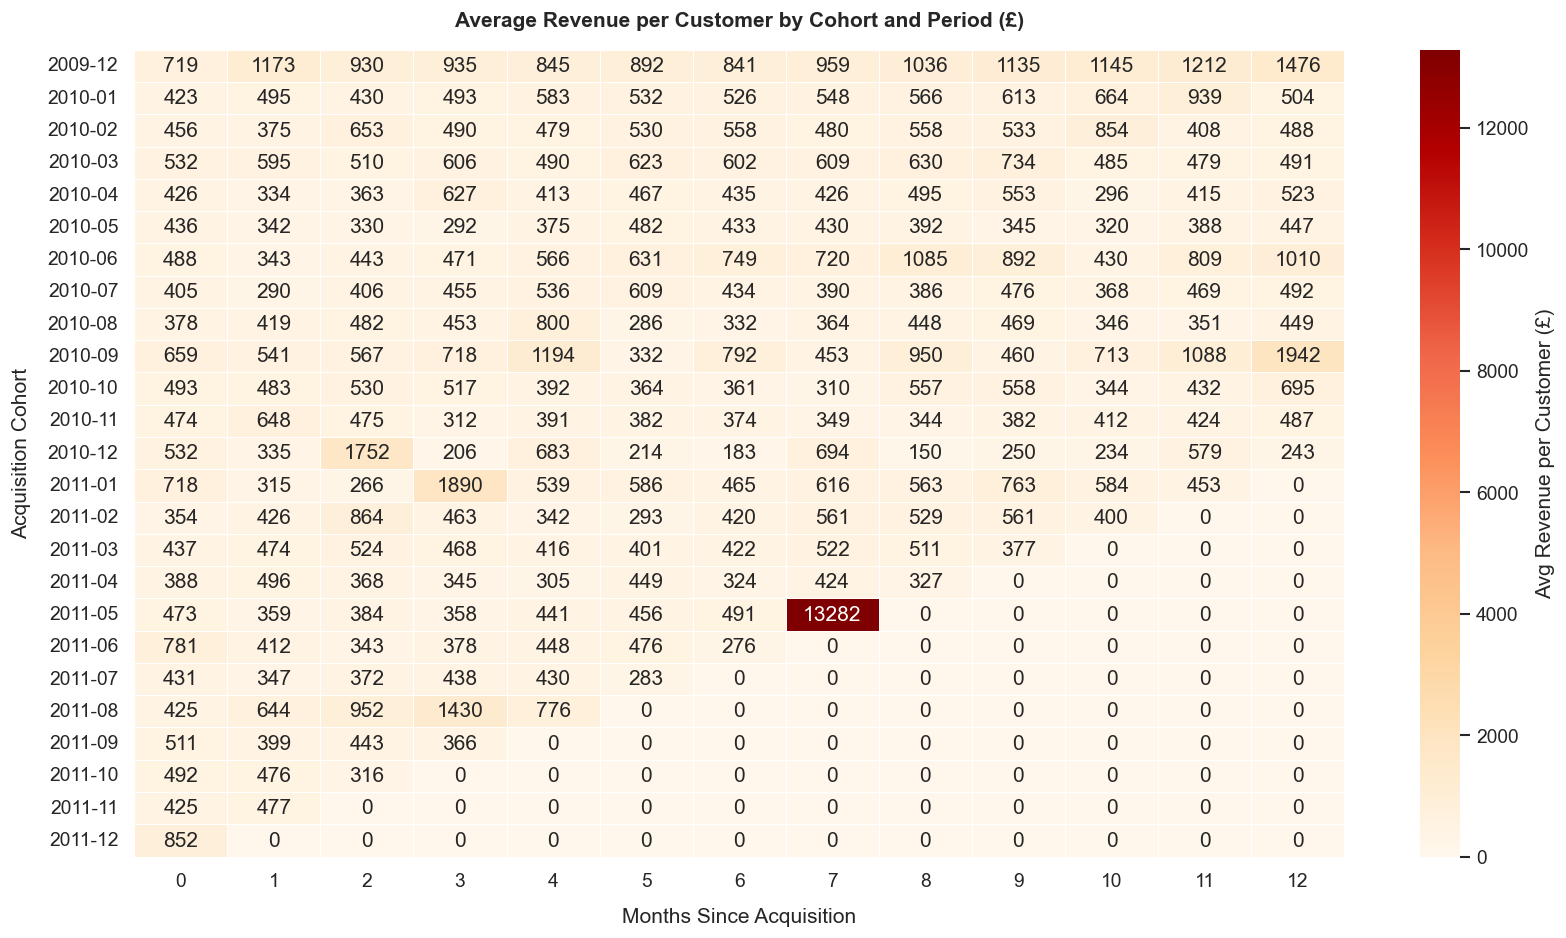

In [13]:
# ── Average revenue per customer heatmap ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    avg_rev_matrix.fillna(0).round(0),
    annot=True,
    fmt='.0f',
    cmap='OrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Avg Revenue per Customer (£)'},
    ax=ax,
)

ax.set_xlabel('Months Since Acquisition', labelpad=10)
ax.set_ylabel('Acquisition Cohort', labelpad=10)
ax.set_title('Average Revenue per Customer by Cohort and Period (£)', fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

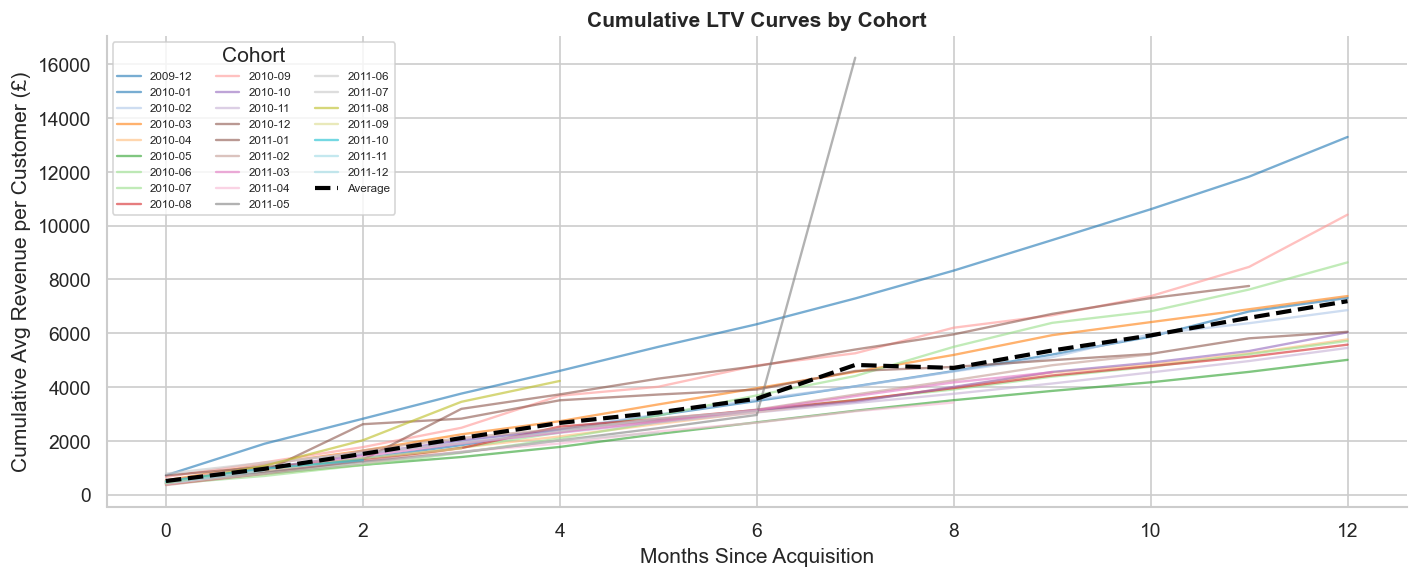

In [14]:
# ── Cumulative LTV curves by cohort ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

cmap = plt.cm.get_cmap('tab20', len(ltv_matrix))

for i, (cohort, row) in enumerate(ltv_matrix.iterrows()):
    valid = row.dropna()
    ax.plot(
        valid.index, valid.values,
        color=cmap(i), alpha=0.6, linewidth=1.4, label=str(cohort)
    )

# Average LTV curve
avg_ltv = ltv_matrix.mean()
ax.plot(
    avg_ltv.index, avg_ltv.values,
    color='black', linewidth=2.5, linestyle='--', label='Average'
)

ax.set_xlabel('Months Since Acquisition')
ax.set_ylabel('Cumulative Avg Revenue per Customer (£)')
ax.set_title('Cumulative LTV Curves by Cohort', fontweight='bold')
ax.legend(loc='upper left', ncol=3, fontsize=7, title='Cohort')
plt.tight_layout()
plt.show()

In [15]:
# ── Rank cohorts by 12-month cumulative LTV ───────────────────────────────
if 12 in ltv_matrix.columns:
    ltv_12 = ltv_matrix[12].dropna().sort_values(ascending=False)
    print('Top 5 cohorts by 12-month cumulative LTV (£ per customer):')
    print(ltv_12.head())
    print('\nBottom 5 cohorts:')
    print(ltv_12.tail())

Top 5 cohorts by 12-month cumulative LTV (£ per customer):
CohortMonth
2009-12    13298.578055
2010-09    10410.564646
2010-06     8636.708975
2010-03     7384.570550
2010-01     7315.564462
Name: 12, dtype: float64

Bottom 5 cohorts:
CohortMonth
2010-04    5773.316438
2010-07    5715.722040
2010-08    5576.998486
2010-11    5455.368650
2010-05    5012.318335
Name: 12, dtype: float64


### Interpretation

LTV curves reveal which cohorts compound their early spend over time versus which plateau quickly. Cohorts acquired during peak retail periods (pre-Christmas) often have higher early revenue but may not sustain it — distinguishing acquisition-period spend from durable purchasing behaviour is an important nuance in LTV modelling.

The average LTV curve sets a benchmark. Cohorts above the average in 12-month LTV are candidates for understanding what drove their outsized value — acquisition channel, product mix, geography — information that would be used to weight marketing spend toward those sources.

## 6. Funnel Analysis

A purchase funnel tracks what proportion of customers reach each successive depth of engagement. Here we define funnel stages by number of distinct invoices per customer:

| Stage | Definition |
|---|---|
| Stage 1 | Made any purchase (all customers) |
| Stage 2 | Made 2+ distinct purchases (repeat buyer) |
| Stage 3 | Made 3+ distinct purchases |
| Stage 4 | Made 6+ distinct purchases (high-frequency buyer) |

Stage-level conversion rates and a logistic regression identify which customer or order-level attributes predict conversion from first-time to repeat buyer.

In [16]:
# ── Build customer-level summary table ────────────────────────────────────
customer_summary = (
    df
    .groupby('CustomerID')
    .agg(
        NumOrders     = ('Invoice', 'nunique'),
        TotalRevenue  = ('Revenue', 'sum'),
        TotalItems    = ('Quantity', 'sum'),
        FirstOrder    = ('InvoiceDate', 'min'),
        LastOrder     = ('InvoiceDate', 'max'),
        NumCountries  = ('Country', 'nunique'),
        AvgOrderValue = ('Revenue', lambda x: x.groupby(df.loc[x.index, 'Invoice']).sum().mean())
    )
    .reset_index()
)

# Days between first and last order (customer tenure)
customer_summary['TenureDays'] = (
    customer_summary['LastOrder'] - customer_summary['FirstOrder']
).dt.days

print(f'Customer summary rows: {len(customer_summary):,}')
customer_summary.describe().round(2)

Customer summary rows: 5,878


,NumOrders,TotalRevenue,TotalItems,FirstOrder,LastOrder,NumCountries,AvgOrderValue,TenureDays
count,5878.00,5878.00,5878.00,5878,5878,5878.00,5878.00,5878.00
mean,6.29,3018.62,1821.40,2010-08-22 06:57:33.297039616,2011-05-22 16:19:59.469207296,1.00,391.73,273.02
min,1.00,2.95,1.00,2009-12-01 07:45:00,2009-12-01 09:55:00,1.00,2.95,0.00
25%,1.00,348.76,190.00,2010-02-09 14:01:15,2010-11-25 10:24:45,1.00,181.65,0.00
50%,3.00,898.92,491.50,2010-06-27 13:31:30,2011-09-05 11:59:00,1.00,285.07,220.50
75%,7.00,2307.09,1376.00,2011-01-30 14:30:15,2011-11-14 11:31:15,1.00,420.57,511.00
max,398.00,608821.65,367193.00,2011-12-09 12:16:00,2011-12-09 12:50:00,2.00,84236.25,738.00
std,13.01,14737.73,8963.01,NaN,NaN,0.05,1215.07,258.81


In [17]:
# ── Funnel stage assignment ───────────────────────────────────────────────
stages = {
    'Stage 1 — Any Purchase':        customer_summary['NumOrders'] >= 1,
    'Stage 2 — Repeat Buyer (2+)':   customer_summary['NumOrders'] >= 2,
    'Stage 3 — Engaged (3+)':        customer_summary['NumOrders'] >= 3,
    'Stage 4 — High-Freq (6+)':      customer_summary['NumOrders'] >= 6,
}

funnel_counts = {label: mask.sum() for label, mask in stages.items()}
funnel_df = pd.DataFrame({
    'Stage': list(funnel_counts.keys()),
    'Customers': list(funnel_counts.values()),
})

total = funnel_df['Customers'].iloc[0]
funnel_df['PctOfTotal']     = (funnel_df['Customers'] / total * 100).round(1)
funnel_df['ConversionRate'] = (
    funnel_df['Customers'] / funnel_df['Customers'].shift(1) * 100
).round(1)

print(funnel_df.to_string(index=False))

                      Stage  Customers  PctOfTotal  ConversionRate
     Stage 1 — Any Purchase       5878       100.0             NaN
Stage 2 — Repeat Buyer (2+)       4255        72.4            72.4
     Stage 3 — Engaged (3+)       3311        56.3            77.8
   Stage 4 — High-Freq (6+)       1801        30.6            54.4


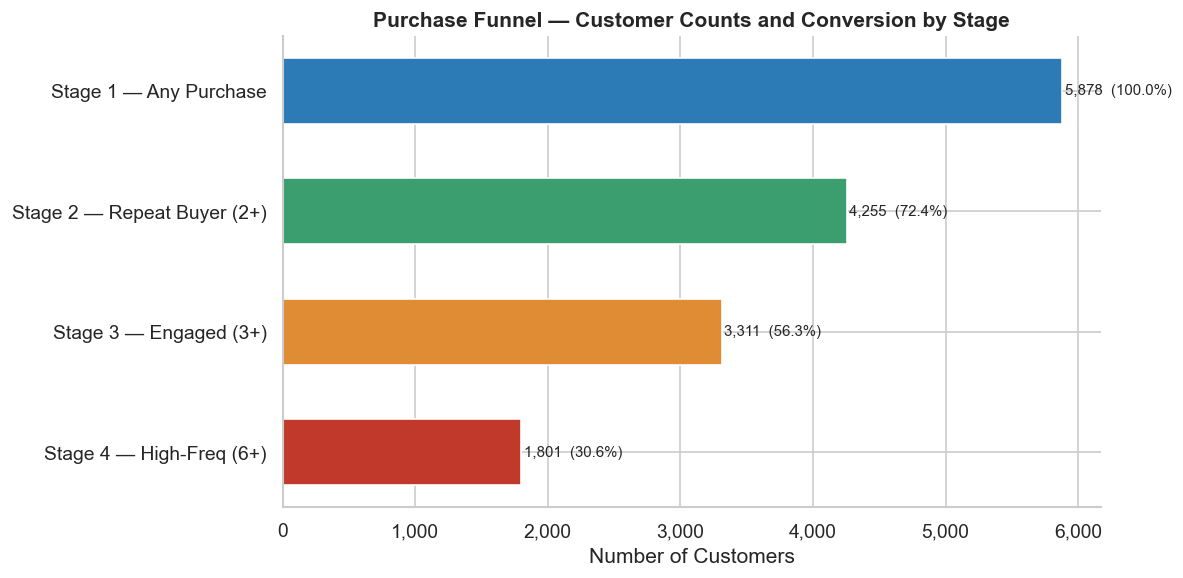

In [18]:
# ── Funnel bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors_funnel = [BLUE, GREEN, ORANGE, RED]
bars = ax.barh(
    funnel_df['Stage'][::-1],
    funnel_df['Customers'][::-1],
    color=colors_funnel[::-1],
    height=0.55,
)

# Annotate with customer count and % of total
for bar, (_, row) in zip(bars, funnel_df[::-1].iterrows()):
    ax.text(
        bar.get_width() + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{row['Customers']:,}  ({row['PctOfTotal']}%)",
        va='center', fontsize=9
    )

ax.set_xlabel('Number of Customers')
ax.set_title('Purchase Funnel — Customer Counts and Conversion by Stage', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 6.1 Drop-off Analysis

In [19]:
# ── Compare first-time vs. repeat buyers on key dimensions ───────────────
customer_summary['IsRepeat'] = (customer_summary['NumOrders'] >= 2).astype(int)

comparison = (
    customer_summary
    .groupby('IsRepeat')
    .agg(
        Customers      = ('CustomerID', 'count'),
        AvgOrders      = ('NumOrders', 'mean'),
        AvgRevenue     = ('TotalRevenue', 'mean'),
        AvgOrderValue  = ('AvgOrderValue', 'mean'),
        AvgTenureDays  = ('TenureDays', 'mean'),
    )
    .round(2)
)
comparison.index = ['First-Time Only', 'Repeat Buyer']
print(comparison)

                 Customers  AvgOrders  AvgRevenue  AvgOrderValue  \
First-Time Only       1623       1.00      350.08         350.08   
Repeat Buyer          4255       8.31     4036.49         407.61   

                 AvgTenureDays  
First-Time Only           0.00  
Repeat Buyer            377.16  


### 6.2 Logistic Regression — Predictors of Conversion to Repeat Buyer

We model the binary outcome `IsRepeat` (converted to Stage 2 or not) as a function of customer-level features observable at or shortly after the first purchase. This gives us a probability-of-return estimate that could be used for targeted re-engagement.

In [20]:
# ── Feature engineering for logistic regression ───────────────────────────
# We use only features knowable at the time of a customer's first purchase
# or shortly after — avoiding data leakage.

# First-order statistics per customer
first_order = (
    df
    .sort_values('InvoiceDate')
    .groupby('CustomerID')
    .first()
    .reset_index()
    [['CustomerID', 'Invoice', 'Country']]
)

# Revenue and item count of the first invoice
first_invoice_agg = (
    df
    .merge(first_order[['CustomerID', 'Invoice']], on=['CustomerID', 'Invoice'])
    .groupby('CustomerID')
    .agg(
        FirstOrderRevenue  = ('Revenue', 'sum'),
        FirstOrderItems    = ('Quantity', 'sum'),
        FirstOrderProducts = ('StockCode', 'nunique'),
    )
    .reset_index()
)

# Is the customer from the UK?
first_order['IsUK'] = (first_order['Country'] == 'United Kingdom').astype(int)

# Merge into modelling table
model_df = (
    customer_summary[['CustomerID', 'IsRepeat']]
    .merge(first_invoice_agg, on='CustomerID')
    .merge(first_order[['CustomerID', 'IsUK']], on='CustomerID')
    .dropna()
)

# Log-transform skewed revenue features
model_df['LogFirstRevenue']  = np.log1p(model_df['FirstOrderRevenue'])
model_df['LogFirstItems']    = np.log1p(model_df['FirstOrderItems'])

print(f'Modelling dataset: {len(model_df):,} customers')
print(f'Repeat rate: {model_df["IsRepeat"].mean():.1%}')

Modelling dataset: 5,878 customers
Repeat rate: 72.4%


In [21]:
# ── Train / test split and logistic regression ────────────────────────────
features = ['LogFirstRevenue', 'LogFirstItems', 'FirstOrderProducts', 'IsUK']
X = model_df[features]
y = model_df['IsRepeat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

logit = LogisticRegression(max_iter=500, random_state=42)
logit.fit(X_train_sc, y_train)

y_pred = logit.predict(X_test_sc)
y_prob = logit.predict_proba(X_test_sc)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.01      0.02       325
           1       0.72      1.00      0.84       851

    accuracy                           0.72      1176
   macro avg       0.61      0.50      0.43      1176
weighted avg       0.66      0.72      0.61      1176

ROC-AUC: 0.585


In [22]:
# ── Statsmodels logit for interpretable coefficients ─────────────────────
X_sm = sm.add_constant(X_train_sc)
logit_sm = sm.Logit(y_train, X_sm).fit(disp=0)

# Odds ratios and 95% CIs
coef_table = pd.DataFrame({
    'Feature'  : ['Intercept'] + features,
    'Coef'     : logit_sm.params,
    'OddsRatio': np.exp(logit_sm.params),
    'CI_Low'   : np.exp(logit_sm.conf_int()[0]),
    'CI_High'  : np.exp(logit_sm.conf_int()[1]),
    'p_value'  : logit_sm.pvalues,
}).set_index('Feature').drop('Intercept')

print('Odds Ratios for Repeat Purchase Conversion:')
print(coef_table.round(3))

Odds Ratios for Repeat Purchase Conversion:
                     Coef  OddsRatio  CI_Low  CI_High  p_value
Feature                                                       
LogFirstRevenue     0.260      1.297   1.161    1.449    0.000
LogFirstItems       0.042      1.042   0.937    1.160    0.445
FirstOrderProducts  0.072      1.075   0.988    1.170    0.092
IsUK                0.082      1.085   1.017    1.158    0.013


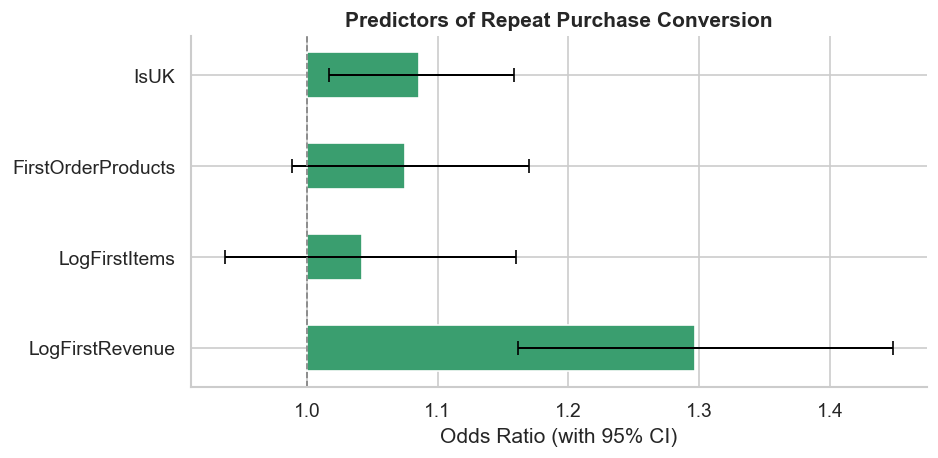

In [23]:
# ── Coefficient plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

y_pos = range(len(coef_table))
ax.barh(
    y_pos,
    coef_table['OddsRatio'] - 1,  # distance from OR=1
    left=1,
    color=[GREEN if v > 1 else RED for v in coef_table['OddsRatio']],
    height=0.5,
)
ax.errorbar(
    coef_table['OddsRatio'],
    y_pos,
    xerr=[
        coef_table['OddsRatio'] - coef_table['CI_Low'],
        coef_table['CI_High'] - coef_table['OddsRatio']
    ],
    fmt='none', color='black', capsize=4, linewidth=1.2
)
ax.axvline(1, color='grey', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(coef_table.index)
ax.set_xlabel('Odds Ratio (with 95% CI)')
ax.set_title('Predictors of Repeat Purchase Conversion', fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

The funnel quantifies where customer drop-off is sharpest — typically at Stage 1 → 2 (first to repeat purchase), which is the highest-leverage intervention point for a product or marketing team. A customer who returns once is substantially more likely to become a habitual buyer than one who does not.

The logistic regression identifies features of a customer's first purchase that predict repeat conversion. Odds ratios above 1 indicate a positive association with repeat purchase; below 1 indicate a negative association. Log-transforming revenue and quantity handles right skew and puts coefficients on a comparable scale. UK customers and higher first-order product diversity are plausible predictors of repeat engagement in this dataset — the retailer's core market is UK-based wholesale buyers with broad product needs.

**Important caveat:** features were constructed from the same transactional dataset used to define the outcome. In a production deployment, care is required to ensure that features are computed from data available at the time of prediction — no post-purchase information should leak into the feature set.

## 7. RFM Segmentation

RFM (Recency, Frequency, Monetary) segmentation is a standard customer analytics framework. Each customer receives a score on three dimensions:

- **Recency (R):** How recently did the customer last purchase? (days since last order — lower is better)
- **Frequency (F):** How many times did the customer purchase? (number of distinct invoices)
- **Monetary (M):** How much did the customer spend in total?

K-means clustering on standardised RFM scores groups customers into behaviorally distinct segments. We then profile each segment to produce actionable labels (Champions, Loyal, At-Risk, Lost).

In [24]:
# ── Define reference date as one day after the last transaction ───────────
ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# ── Compute RFM per customer ──────────────────────────────────────────────
rfm = (
    df
    .groupby('CustomerID')
    .agg(
        Recency   = ('InvoiceDate', lambda x: (ref_date - x.max()).days),
        Frequency = ('Invoice', 'nunique'),
        Monetary  = ('Revenue', 'sum'),
    )
    .reset_index()
)

print(rfm.describe().round(2))

       Recency  Frequency   Monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    3018.62
std     209.34      13.01   14737.73
min       1.00       1.00       2.95
25%      26.00       1.00     348.76
50%      96.00       3.00     898.92
75%     380.00       7.00    2307.09
max     739.00     398.00  608821.65


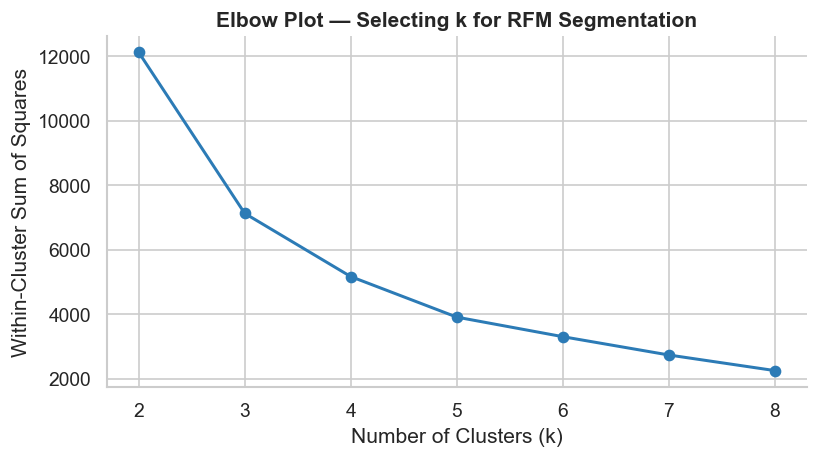

In [25]:
# ── Standardise RFM scores for K-means ───────────────────────────────────
# Recency is inverted so that higher = more recent (better)
rfm_scaled = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_scaled['Recency'] = rfm_scaled['Recency'] * -1   # invert

scaler_rfm = StandardScaler()
rfm_array  = scaler_rfm.fit_transform(rfm_scaled)

# ── Elbow plot to select k ────────────────────────────────────────────────
inertias = []
K_range  = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_array)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, marker='o', color=BLUE, linewidth=1.8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Within-Cluster Sum of Squares')
ax.set_title('Elbow Plot — Selecting k for RFM Segmentation', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# ── Fit K-means with chosen k (adjust based on elbow plot) ───────────────
K_CHOSEN = 4

km_final = KMeans(n_clusters=K_CHOSEN, random_state=42, n_init=10)
rfm['Segment'] = km_final.fit_predict(rfm_array)

# ── Profile each segment ──────────────────────────────────────────────────
segment_profile = (
    rfm
    .groupby('Segment')
    .agg(
        Customers    = ('CustomerID', 'count'),
        AvgRecency   = ('Recency', 'mean'),
        AvgFrequency = ('Frequency', 'mean'),
        AvgMonetary  = ('Monetary', 'mean'),
    )
    .round(1)
)

print(segment_profile)

         Customers  AvgRecency  AvgFrequency  AvgMonetary
Segment                                                  
0             1998       463.0           2.2        765.2
1             3841        67.0           7.3       3009.4
2               35        25.9         103.7      83086.1
3                4         3.5         212.5     436835.8


In [27]:
# ── Assign interpretable labels based on segment profiles ─────────────────
# Labels are assigned manually after reviewing the profile table above.
# Sort by AvgFrequency to help with consistent labelling.
ranked = segment_profile.sort_values('AvgFrequency', ascending=False)
labels = ['Champions', 'Loyal', 'At-Risk', 'Lost']
label_map = dict(zip(ranked.index, labels))

rfm['SegmentLabel'] = rfm['Segment'].map(label_map)
segment_profile['Label'] = segment_profile.index.map(label_map)

print('\nSegment labels:')
print(segment_profile[['Label', 'Customers', 'AvgRecency', 'AvgFrequency', 'AvgMonetary']])


Segment labels:
             Label  Customers  AvgRecency  AvgFrequency  AvgMonetary
Segment                                                             
0             Lost       1998       463.0           2.2        765.2
1          At-Risk       3841        67.0           7.3       3009.4
2            Loyal         35        25.9         103.7      83086.1
3        Champions          4         3.5         212.5     436835.8


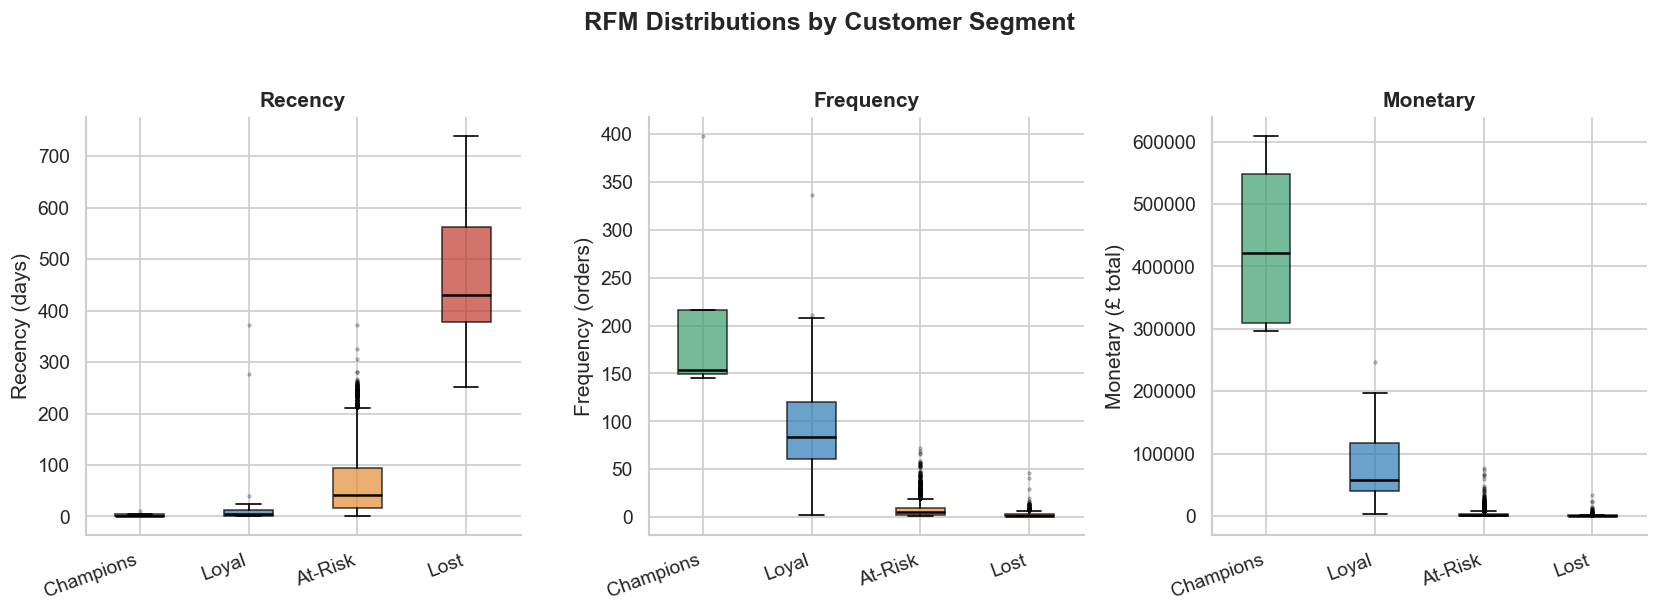

In [28]:
# ── RFM segment visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

palette = {'Champions': GREEN, 'Loyal': BLUE, 'At-Risk': ORANGE, 'Lost': RED}
dims    = ['Recency', 'Frequency', 'Monetary']
labels_plot = ['Recency (days)', 'Frequency (orders)', 'Monetary (£ total)']

for ax, dim, label in zip(axes, dims, labels_plot):
    order = ['Champions', 'Loyal', 'At-Risk', 'Lost']
    data  = [rfm.loc[rfm['SegmentLabel'] == seg, dim].values for seg in order]
    bp = ax.boxplot(
        data,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        flierprops=dict(marker='.', markersize=3, alpha=0.3),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
    )
    for patch, seg in zip(bp['boxes'], order):
        patch.set_facecolor(palette[seg])
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order, rotation=20, ha='right')
    ax.set_ylabel(label)
    ax.set_title(dim, fontweight='bold')

plt.suptitle('RFM Distributions by Customer Segment', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Repeat purchase rate by RFM segment:
              RepeatRate     N
SegmentLabel                  
Champions          100.0     4
Loyal              100.0    35
At-Risk             85.4  3841
Lost                46.9  1998


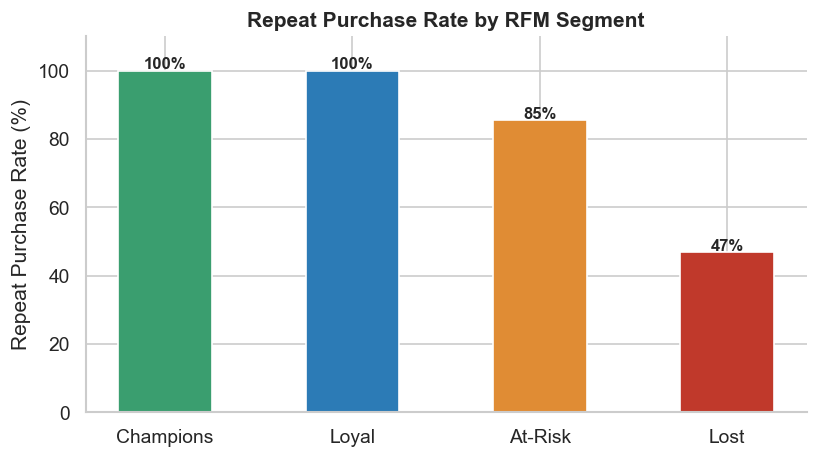

In [29]:
# ── Retention rate by RFM segment ─────────────────────────────────────────
rfm_retention = (
    rfm
    .merge(customer_summary[['CustomerID', 'IsRepeat']], on='CustomerID')
    .groupby('SegmentLabel')['IsRepeat']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'RepeatRate', 'count': 'N'})
    .assign(RepeatRate=lambda x: x['RepeatRate'] * 100)
    .loc[['Champions', 'Loyal', 'At-Risk', 'Lost']]
    .round(1)
)

print('Repeat purchase rate by RFM segment:')
print(rfm_retention)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    rfm_retention.index,
    rfm_retention['RepeatRate'],
    color=[palette[s] for s in rfm_retention.index],
    width=0.5
)
for bar, (seg, row) in zip(bars, rfm_retention.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['RepeatRate']:.0f}%",
        ha='center', fontsize=10, fontweight='bold'
    )
ax.set_ylabel('Repeat Purchase Rate (%)')
ax.set_title('Repeat Purchase Rate by RFM Segment', fontweight='bold')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

### Interpretation

K-means on standardised RFM scores partitions customers into behaviorally distinct groups. The elbow plot guides cluster count selection — the inflection point where adding more clusters yields diminishing reduction in within-cluster variance.

**Champions** are high-frequency, high-monetary, recent buyers — the top-tier customer segment worth protecting through loyalty recognition. **Loyal** customers have strong purchase histories but may be slightly less recent. **At-Risk** customers have not purchased recently but have historical engagement — candidates for targeted re-engagement campaigns. **Lost** customers have low recency, low frequency, and low spend.

Retention rate by segment validates the segmentation: if Champions have materially higher repeat rates than Lost customers, the clustering has captured something real about behavioral propensity, not just demographic noise.

## 8. Results Summary

### Key Findings

**Retention:**  
The cohort heatmap shows the characteristic retention profile of a transactional retailer — a sharp drop from acquisition to Month 1, followed by a longer tail of habitual buyers. Month-1 and Month-3 retention rates serve as the headline KPIs a product team would track over time to evaluate onboarding and early lifecycle interventions.

**LTV:**  
Cumulative LTV curves reveal variation in long-term value across acquisition cohorts that is not visible from retention alone. Cohorts with lower Month-1 retention but higher average order values can still outperform high-retention, low-spend cohorts by Month 12. This underscores the importance of tracking both dimensions in parallel.

**Funnel:**  
The sharpest drop-off is at Stage 1 → 2 — the first-to-repeat conversion. This is the highest-leverage point for intervention: a re-engagement campaign targeting customers who completed one purchase but have not returned within 30–60 days would directly address the largest source of customer attrition.

**Predictors of Repeat Purchase:**  
Logistic regression identifies first-order characteristics that are predictive of repeat conversion. Higher first-order revenue and broader product diversity on the first order are positively associated with returning — consistent with the idea that customers who explore the catalogue on their first visit have broader purchase intent.

**RFM Segmentation:**  
K-means clustering on RFM scores produces four actionable segments. Retention rates validate that the segments reflect genuine behavioral differences. Champions and Loyal segments warrant retention investment; At-Risk warrants re-engagement outreach; Lost customers may warrant win-back campaigns or disinvestment depending on acquisition cost.

---

### Limitations and Caveats

**No acquisition channel data:** All customers are pooled regardless of how they were acquired. In practice, retention curves vary substantially by channel (paid search, email, organic) — a channel-stratified analysis would be the natural next step with richer data.

**B2B customer mix:** This retailer has a strong wholesale customer base. B2B and B2C customers have fundamentally different purchase cadences — segmenting by customer type before running retention analysis would produce more interpretable cohorts.

**Logistic regression feature set:** Features were limited to what is observable at or near the first purchase to avoid data leakage. A richer feature set — product category, country, device type — would likely improve predictive performance.

**K-means sensitivity:** K-means is sensitive to initialisation and the choice of k. The elbow method provides guidance but not a definitive answer. Alternative approaches (silhouette score, hierarchical clustering) would be worth comparing in a production analysis.

**Temporal censoring:** Cohorts acquired later in the study window have shorter observable follow-up periods. Month-12 LTV and retention estimates for recent cohorts are based on fewer observations and should be treated with more uncertainty.